# Descriptive Statistics Problems

## Exercise 1 – How long are movie titles?

In this exercise, you will apply descriptive statistics techniques to a real dataset: a database of 1000 popular movies from the IMDb website.

From the title of each movie, you will:
- Calculate the title length (in characters).
- Obtain key statistical metrics: mean, median, mode, range, variance, standard deviation, skewness, and kurtosis.
- Identify the longest and shortest titles.
- Visualize the distribution of these lengths with a histogram and a density curve.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, mode

# Load IMDb dataset
url = "../assets/imdb_1000.csv"
df = pd.read_csv(url)
df

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [3]:
# Create a new column called 'title_length' with the length (number of characters) of each title
df["title_length"] = df["title"].str.len()
df

,star_rating,title,content_rating,genre,duration,actors_list,title_length
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt...",24
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']",13
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv...",22
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E...",15
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L....",12
...,...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G...",7
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma...",27
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo...",47
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr...",11


In [4]:
# Calculate mean, median, and mode of the 'title_length' column
# Mean
mean_val = df["title_length"].mean()

# Median
median_val = df["title_length"].median()

# Mode
mode_val = df["title_length"].mode()

print(f"{mean_val}\n{median_val}\n{mode_val}")

15.481103166496425
14.0
0    12
Name: title_length, dtype: int64


In [5]:
# Calculate the range, variance, and standard deviation of 'title_length'
# Range
range_val = df["title_length"].max() - df["title_length"].min()

# Variance
variance_val = df["title_length"].var()

# Standard deviation
std_val = df["title_length"].std()

print(f"{range_val}\n{variance_val}\n{std_val}")

67
72.1067488840288
8.491569282766807


In [6]:
# Calculate skewness and kurtosis of the 'title_length' column
# Skewness
skew_val = df["title_length"].skew()

# Kurtosis
kurt_val = df["title_length"].kurt()

print(f"{skew_val}\n{kurt_val}")

1.5252523464631278
3.8122887061291544


In [7]:
# Print the shortest and longest title based on their length
range_max_val = df[df['title_length'] == df['title_length'].max()]
range_min_val = df[df['title_length'] == df['title_length'].min()]
print(f"Movies with the longest titles:\n{range_max_val}\n")
print(f"Movies with the shortest titles:\n{range_min_val}")

Movies with the longest titles:
    star_rating                                              title  \
48          8.5  Dr. Strangelove or: How I Learned to Stop Worr...   

   content_rating   genre  duration  \
48             PG  Comedy        95   

                                          actors_list  title_length  
48  [u'Peter Sellers', u'George C. Scott', u'Sterl...            68  

Movies with the shortest titles:
    star_rating title content_rating  genre  duration  \
63          8.4     M      NOT RATED  Crime        99   

                                          actors_list  title_length  
63  [u'Peter Lorre', u'Ellen Widmann', u'Inge Land...             1  


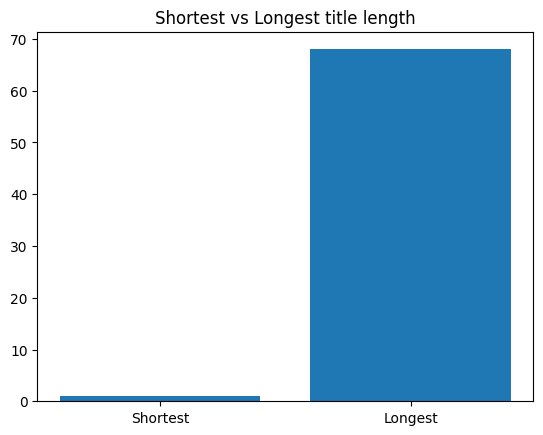

In [9]:
# plot your results
max_len = range_max_val["title_length"].iloc[0]
min_len = range_min_val["title_length"].iloc[0]
labels = ["Shortest", "Longest"]
values = [min_len, max_len]

plt.figure()
plt.bar(labels, values)
plt.title("Shortest vs Longest title length")
plt.show()


---

## Exercise 2 – Manual Calculation of Standard Deviation

In this exercise, you will manually calculate the standard deviation by selecting five actual titles from the movie dataset you loaded earlier.


In [19]:
# Create a list with 5 actual values from df['title_length'], for example: [10, 13, 14, 18, 22]
random_nums = df['title_length'].sample(n=5)
ls = random_nums.to_list()
print(ls)

[8, 6, 25, 12, 10]


In [22]:
# Calculate the mean of the 5 values
mean_val = random_nums.mean()
print(mean_val)

12.2


In [34]:
# Calculate the squared differences with respect to the mean
squared_diff_val = random_nums.apply(lambda x: (x - mean_val) ** 2)
for n in squared_diff_val.to_list():
    print(f"{n:.2f}")

17.64
38.44
163.84
0.04
4.84


In [35]:
# Calculate the variance (average of the squared differences) and its square root to obtain the standard deviation
variance = squared_diff_val.mean()
std_dev = variance ** 0.5
print(f"{variance}\n{std_dev}")

44.96
6.705221845696084
